Check out all the code and files here: [GitHub Repository](https://github.com/yourusername/yourrepo)

In [5]:
#All the necessary imports:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler



In [6]:

#Making this notbook colorblind accessible
# Wong (2011) colorblind-safe palette
# Source: Wong, B. (2011). Color blindness. Nature Methods, 8(6), 441.
# Safe for ALL forms of color vision deficiency.

CB = {
    "black":      "#000000",
    "orange":     "#E69F00",   # ← validation loss
    "sky":        "#56B4E9",   # ← training loss / secondary
    "green":      "#009E73",   # ← (avoid as primary — can clash with orange for some)
    "yellow":     "#F0E442",
    "blue":       "#0072B2",   # ← NORMAL
    "vermillion": "#D55E00",   # ← accent / point-wise error
    "pink":       "#CC79A7",   # ← tertiary
}

# ── Matplotlib global accessibility settings ──────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "legend.fontsize":    10,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.facecolor":     "#FAFAFA",
    "figure.facecolor":   "white",
    "axes.grid":          True,
    "grid.alpha":         0.35,
    "grid.color":         "#CCCCCC",
    "lines.linewidth":    2.2,
    "patch.linewidth":    1.2,
})

In [7]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
df = pd.read_csv("ecg.csv", header=None)

# Separate features and labels (X denotes features an y represents labels)
X = df.iloc[:, :-1].values
y = df.iloc[:,  -1].values

print(f"  Total samples  : {X.shape[0]}")
print(f"  Time-steps     : {X.shape[1]}")
print(f"  Normal  (y=1)  : {(y == 1).sum()}")
print(f"  Anomaly (y=0)  : {(y == 0).sum()}")



# Preprocessing

"""
  Neural networks train faster and more stably when all features are
  in the same range. MinMaxScaler squishes every time-step to [0, 1].
"""

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data into normal and anomalous
X_normal   = X_scaled[y == 1]
X_anomaly  = X_scaled[y == 0]

"""
  Train only on normal data!
  The autoencoder should learn the distribution of normal ECGs.
  It should never see anomalies during training.
"""
X_train, X_val = train_test_split(X_normal, test_size=0.1, random_state=SEED)

print(f"  Training data : {X_train.shape}")
print(f"  Validation data : {X_val.shape}")


  Total samples  : 4998
  Time-steps     : 140
  Normal  (y=1)  : 2919
  Anomaly (y=0)  : 2079
  Training data : (2627, 140)
  Validation data : (292, 140)


In [8]:
#  Build the Autoencoder Model


"""
  • Encoder squeezes 140 numbers → 16 (compression)
  • Decoder tries to reproduce the original 140 numbers
"""

input  = X_train.shape[1]   # 140
latent  = 16                 # bottleneck size

def build_autoencoder(input_dim: int, latent_dim: int):
    #  Encoder
    inputs = keras.Input(shape=(input_dim,), name="encoder_input")
    x = layers.Dense(64, activation="relu", name="enc_dense1")(inputs)
    x = layers.Dense(32, activation="relu", name="enc_dense2")(x)
    encoded = layers.Dense(latent_dim, activation="relu", name="bottleneck")(x)

    #  Decoder
    x = layers.Dense(32, activation="relu", name="dec_dense1")(encoded)
    x = layers.Dense(64, activation="relu", name="dec_dense2")(x)
    decoded = layers.Dense(input_dim, activation="sigmoid", name="decoder_output")(x)

    model = keras.Model(inputs, decoded, name="ECG_Autoencoder")
    return model

autoencoder = build_autoencoder(input,latent)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "ECG_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1 (Dense)              │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense2 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1 (Dense)              │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 140)            │         9,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,388 (91.36 KB)

 Trainable params: 23,388 (91.36 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#  Train the Autoencoder

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0161 - val_loss: 0.0052
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020 - val_l

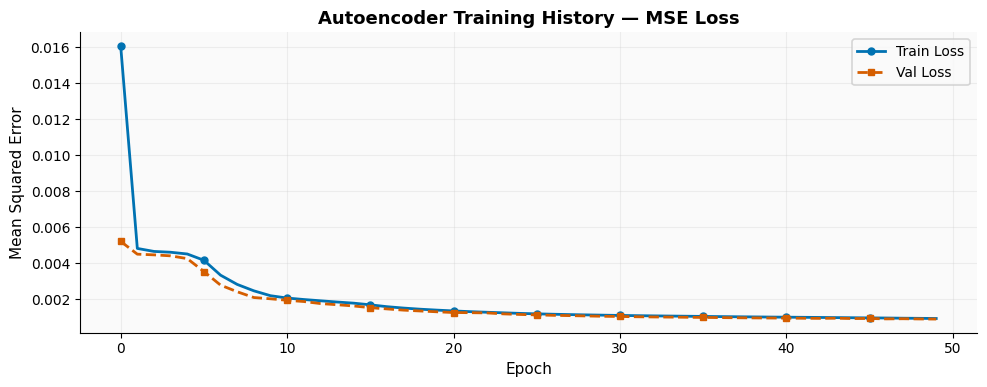

In [10]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Train Loss", color=CB['blue'],  linestyle="-",  marker="o", markevery=5,
        markersize=5, linewidth=2)
ax.plot(history.history["val_loss"], label="Val Loss",color=CB["vermillion"], linestyle="--", marker="s", markevery=5,
        markersize=5, linewidth=2)
ax.set_title("Autoencoder Training History — MSE Loss", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()


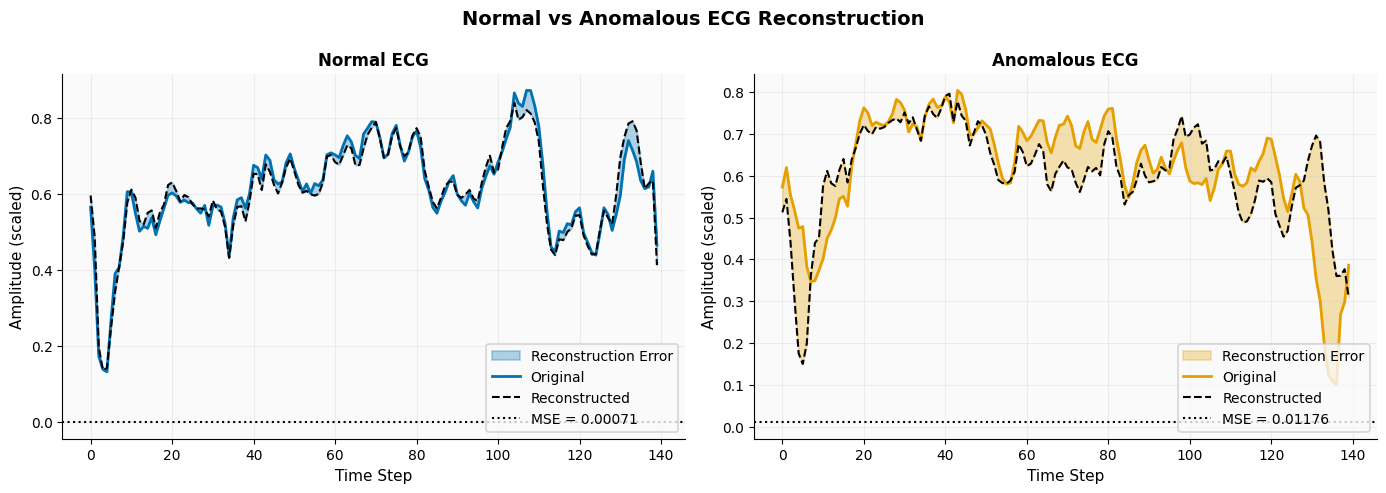

In [11]:
#  Reconstruction: Normal vs Anomalous

"""
  • Normal ECG  → low reconstruction error  (model knows it well)
  • Anomaly ECG → high reconstruction error (model cannot reproduce it)
"""

def plot_reconstruction(model, original, title, color, ax):
    reconstructed = model.predict(original[np.newaxis, :], verbose=0)[0]

    # Mean Squared Error
    error = np.abs(original - reconstructed)
    mse = np.mean(error**2)

    # Fill the error region
    ax.fill_between(range(len(original)), original, reconstructed,
                    color=color, alpha=0.3, label="Reconstruction Error")

    # Plot original and reconstructed
    ax.plot(original,      label="Original",      color=color,   linewidth=2)
    ax.plot(reconstructed, label="Reconstructed", color=CB["black"], linewidth=1.5, linestyle="--")

    # Mean Squared Error
    ax.axhline(mse, color="black", linestyle=":", linewidth=1.5,
               label=f"MSE = {mse:.5f}")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Amplitude (scaled)")
    ax.legend(loc= 'lower right')
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Normal vs Anomalous ECG Reconstruction", fontsize=14, fontweight="bold")

# Normal ECG
plot_reconstruction(autoencoder, X_normal[0], "Normal ECG", CB["blue"],   axes[0])

# Anomalous ECG
plot_reconstruction(autoencoder, X_anomaly[0], "Anomalous ECG",CB["orange"],axes[1])

plt.tight_layout()
plt.savefig("reconstruction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


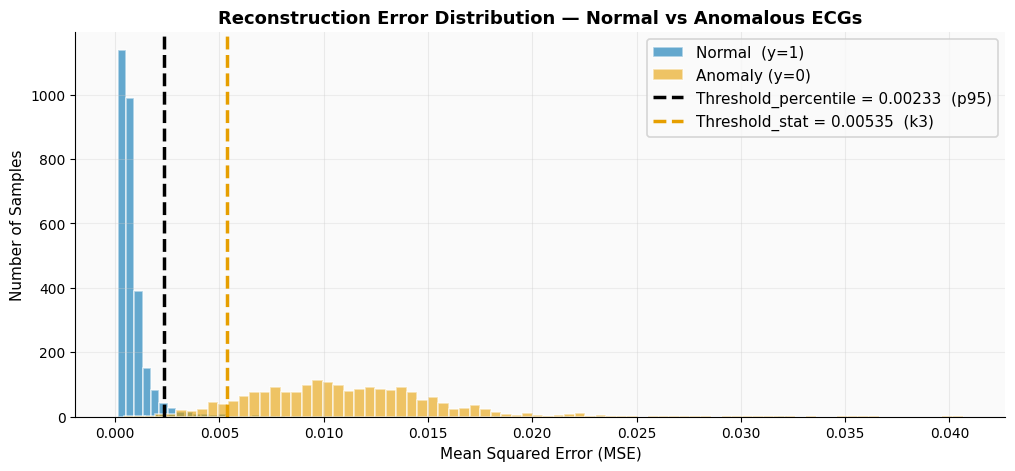

In [12]:
# Compute Reconstruction Errors for All Samples

X_all    = X_scaled
y_all    = y

X_all_reconstructed = autoencoder.predict(X_all, batch_size=256, verbose=0)
mse_all = np.mean(np.power(X_all - X_all_reconstructed, 2), axis=1)
mse_normal  = mse_all[y_all == 1]
mse_anomaly = mse_all[y_all == 0]


# Threshold Selection
"""
Setting threshold
   We calculate both the Gaussian(Statistical) threshold and  the 95th percentile of reconstruction errors on TRAINING data.
   And then choose the suitable threshold which was percentile threshold
"""

# Reconstruct training data to define threshold from "normal" distribution
X_train_reconstructed = autoencoder.predict(X_train, batch_size=256, verbose=0)
mse_train = np.mean(np.power(X_train - X_train_reconstructed, 2), axis=1)

# Setting threshold with percentile method
THRESHOLD_PERCENTILE = 95
THRESHOLD = np.percentile(mse_train, THRESHOLD_PERCENTILE)

# Statistical threshold
mean_mse = np.mean(mse_train)
std_mse = np.std(mse_train)

# Choose k (sensitivity factor)
k = 3
THRESHOLD1= mean_mse + (k * std_mse)

# Distribution Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(mse_normal,  bins=80, alpha=0.6, color=CB["blue"], label="Normal  (y=1)", edgecolor="white")
ax.hist(mse_anomaly, bins=80, alpha=0.6, color=CB["orange"], label="Anomaly (y=0)", edgecolor="white")

ax.axvline(THRESHOLD, color=CB["black"], linewidth=2.5, linestyle="--",
           label=f"Threshold_percentile = {THRESHOLD:.5f}  (p{THRESHOLD_PERCENTILE})")
ax.axvline(THRESHOLD1, color=CB["orange"], linewidth=2.5,  linestyle="--",
           label=f"Threshold_stat = {THRESHOLD1:.5f}  (k{k})")
ax.set_title("Reconstruction Error Distribution — Normal vs Anomalous ECGs",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Squared Error (MSE)", fontsize=11)
ax.set_ylabel("Number of Samples",       fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis="y")
plt.savefig("reconstruction_error_distribution.png", dpi=150, bbox_inches="tight")



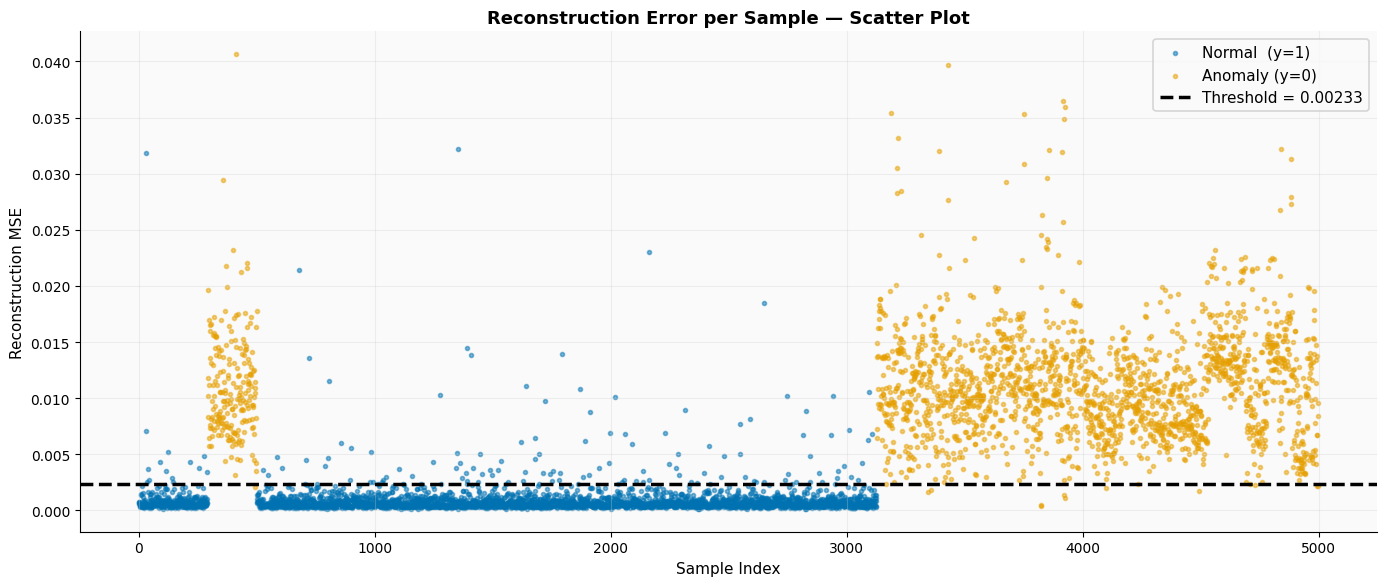

In [13]:

"""
Each dot = one ECG sample.
X-axis = sample index  |  Y-axis = reconstruction MSE
Dots ABOVE the threshold line → predicted as Anomaly.
"""

idx_normal  = np.where(y_all == 1)[0]
idx_anomaly = np.where(y_all == 0)[0]

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(idx_normal,  mse_all[y_all == 1],
           s=8, alpha=0.5,  color=CB["blue"], label="Normal  (y=1)")
ax.scatter(idx_anomaly, mse_all[y_all == 0],
           s=8, alpha=0.5,color=CB["orange"], label="Anomaly (y=0)")

ax.axhline(THRESHOLD, color=CB["black"], linewidth=2.5, linestyle="--",
           label=f"Threshold = {THRESHOLD:.5f}")

ax.set_title("Reconstruction Error per Sample — Scatter Plot", fontsize=13, fontweight="bold")
ax.set_xlabel("Sample Index", fontsize=11)
ax.set_ylabel("Reconstruction MSE", fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

         Precision    Recall  F1 Score
Anomaly   0.936990  0.994228  0.964761
Normal    0.995702  0.952381  0.973560
Accuracy_score: 0.9697879151660664


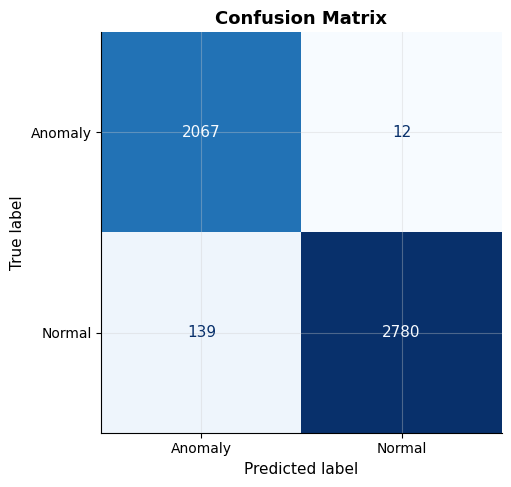

In [14]:

# Evaluate the model: Precision, Recall, F1, Accuracy

y_pred = (mse_all <= THRESHOLD).astype(int)   # 1 = Normal, 0 = Anomaly

from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


precision = precision_score(y_all, y_pred, average=None)
recall = recall_score(y_all, y_pred, average=None)
f1 = f1_score(y_all, y_pred, average=None)

classes = ["Anomaly", "Normal"]
metrics_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}, index=classes)

accuracy = accuracy_score(y_all, y_pred)
print(metrics_df)
print("Accuracy_score:", accuracy)

cm = confusion_matrix(y_all, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Anomaly", "Normal"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()








In [15]:
# Anamoly detection

def predict_ecg_anomaly(sample, model, threshold=THRESHOLD):
    # Ensure input has batch dimension
    sample = sample[np.newaxis, :]  # shape (1, 140)

    reconstructed = model.predict(sample, verbose=0)[0]
    error = sample[0] - reconstructed
    mse_value = float(np.mean(error ** 2))

    # Decide normal vs anomaly
    if mse_value > threshold:
        result = "Anomaly"
    else:
        result = "Normal"

    return result, mse_value, reconstructed, error


# Example usage
new_ecg = X[4997]
result, mse_value, reconstructed, error= predict_ecg_anomaly(new_ecg, autoencoder)
print(f"Sample 296 — Prediction: {result}, Reconstruction error: {mse_value:.5f}")
plot_reconstruction(autoencoder, new_ecg, "Normal ECG", CB["blue"],   axes[0])
plt.show()

Sample 296 — Prediction: Anomaly, Reconstruction error: 1.16909
